# Perlin Noise: Smooth Procedural Randomness

Perlin noise creates smooth pseudo-random patterns. Unlike plain random noise, nearby points are related, so the result looks like rolling terrain, clouds, smoke, marble, or organic texture.

Ken Perlin invented it for computer graphics work on *TRON*, and it became a foundation of procedural generation. Games like Minecraft use noise-style terrain generation to turn math into landscapes.

<details>
<summary>Big idea</summary>

Randomness becomes natural-looking when it is continuous. Perlin noise gives each grid point a random gradient, then smoothly blends those gradients between points.

</details>

## 1. Mental Model

Perlin noise works in four steps:

- Pick random gradient directions at lattice points.
- For each pixel, find the surrounding lattice square.
- Measure how each corner gradient points toward the pixel.
- Smoothly blend the corner values together.

One layer gives smooth hills. Multiple layers, called **octaves**, add smaller details on top.

<details>
<summary>Octave hint</summary>

Each octave increases frequency and usually lowers amplitude. `persistence` controls how much influence the smaller details keep.

</details>

## 2. Build the Objects

We will build a small terrain lab:

- `PerlinGrid` owns the random gradient field.
- `NoiseConfig` stores scale, octaves, persistence, and lacunarity.
- `TerrainSnapshot` records one generated height map.
- `TerrainGenerator` turns smooth noise into a 2D terrain array.
- Plot helpers render the terrain with topographic colors.

<details>
<summary>Implementation hint</summary>

The fade curve $6t^5 - 15t^4 + 10t^3$ makes interpolation smooth at lattice boundaries, which prevents blocky seams.

</details>

**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
from dataclasses import dataclass

import matplotlib.pyplot as plt

import numpy as np

from IPython.display import HTML

from matplotlib import animation

from matplotlib.colors import LinearSegmentedColormap

terrain_cmap = LinearSegmentedColormap.from_list(
    "perlin_terrain",
    [
        "#173F5F",  # deep water
        "#20639B",  # water
        "#3CAEA3",  # shore
        "#7FB069",  # grass
        "#F6D55C",  # dry hills
        "#A0522D",  # rock
        "#F7F7F7",  # snow
    ],
)


**Trace model.** Define `NoiseConfig`, `TerrainSnapshot`, the structure used to capture replayable algorithm state.


In [ ]:
@dataclass(frozen=True)
class NoiseConfig:
    width: int = 128
    height: int = 128
    scale: float = 6.0
    octaves: int = 4
    persistence: float = 0.5
    lacunarity: float = 2.0
    seed: int = 13

@dataclass(frozen=True)
class TerrainSnapshot:
    label: str
    config: NoiseConfig
    heights: np.ndarray

    def stats(self) -> dict[str, float]:
        return {
            "min": float(np.min(self.heights)),
            "max": float(np.max(self.heights)),
            "mean": float(np.mean(self.heights)),
            "std": float(np.std(self.heights)),
        }


**State model.** Define `PerlinGrid`, the data structure the lesson will operate on.


In [ ]:
class PerlinGrid:
    def __init__(self, seed: int = 13, table_size: int = 256):
        self.seed = seed
        self.table_size = table_size
        rng = np.random.default_rng(seed)
        angles = rng.uniform(0, 2 * np.pi, size=table_size)
        self.gradients = np.column_stack((np.cos(angles), np.sin(angles)))
        permutation = rng.permutation(table_size)
        self.permutation = np.concatenate([permutation, permutation])

    @staticmethod
    def fade(values: np.ndarray) -> np.ndarray:
        return values * values * values * (values * (values * 6 - 15) + 10)

    @staticmethod
    def lerp(left: np.ndarray, right: np.ndarray, weight: np.ndarray) -> np.ndarray:
        return left + weight * (right - left)

    def _gradient_index(self, ix: np.ndarray, iy: np.ndarray) -> np.ndarray:
        return self.permutation[(self.permutation[ix % self.table_size] + iy) % self.table_size]

    def _dot_gradient(self, ix: np.ndarray, iy: np.ndarray, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        gradient = self.gradients[self._gradient_index(ix, iy)]
        dx = x - ix
        dy = y - iy
        return gradient[..., 0] * dx + gradient[..., 1] * dy

    def noise(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        x0 = np.floor(x).astype(int)
        y0 = np.floor(y).astype(int)
        x1 = x0 + 1
        y1 = y0 + 1

        sx = self.fade(x - x0)
        sy = self.fade(y - y0)

        n00 = self._dot_gradient(x0, y0, x, y)
        n10 = self._dot_gradient(x1, y0, x, y)
        n01 = self._dot_gradient(x0, y1, x, y)
        n11 = self._dot_gradient(x1, y1, x, y)

        top = self.lerp(n00, n10, sx)
        bottom = self.lerp(n01, n11, sx)
        return self.lerp(top, bottom, sy)


**Object model.** Define `TerrainGenerator`, the named objects used by the next examples.


In [ ]:
class TerrainGenerator:
    def __init__(self, config: NoiseConfig):
        self.config = config
        self.grid = PerlinGrid(seed=config.seed)

    def coordinate_grid(self) -> tuple[np.ndarray, np.ndarray]:
        x = np.linspace(0, self.config.scale, self.config.width, endpoint=False)
        y = np.linspace(0, self.config.scale, self.config.height, endpoint=False)
        return np.meshgrid(x, y)

    def generate(self) -> np.ndarray:
        x, y = self.coordinate_grid()
        total = np.zeros((self.config.height, self.config.width), dtype=float)
        amplitude = 1.0
        frequency = 1.0
        amplitude_sum = 0.0

        for _ in range(self.config.octaves):
            total += amplitude * self.grid.noise(x * frequency, y * frequency)
            amplitude_sum += amplitude
            amplitude *= self.config.persistence
            frequency *= self.config.lacunarity

        normalized = total / amplitude_sum
        return self.normalize(normalized)

    @staticmethod
    def normalize(values: np.ndarray) -> np.ndarray:
        low = np.min(values)
        high = np.max(values)
        if np.isclose(high, low):
            return np.zeros_like(values)
        return (values - low) / (high - low)

    def snapshot(self, label: str) -> TerrainSnapshot:
        return TerrainSnapshot(label=label, config=self.config, heights=self.generate())


**Visual helper.** Define `plot_terrain`, `plot_height_histogram`, which turns state into something students can inspect.


In [ ]:
def plot_terrain(snapshot: TerrainSnapshot, title: str | None = None, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(snapshot.heights, cmap=terrain_cmap, interpolation="bilinear", origin="lower")
    ax.contour(snapshot.heights, levels=9, colors="black", linewidths=0.22, alpha=0.3)
    ax.set_title(title or snapshot.label)
    ax.set_xticks([])
    ax.set_yticks([])
    return image

def plot_height_histogram(snapshot: TerrainSnapshot) -> None:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(snapshot.heights.ravel(), bins=30, color="#3CAEA3", edgecolor="#173F5F", alpha=0.9)
    ax.set_title(f"Height distribution: {snapshot.label}")
    ax.set_xlabel("normalized height")
    ax.set_ylabel("cell count")
    ax.grid(alpha=0.2)
    plt.show()


## 3. Generate Smooth Terrain

Now generate a 2D height map. Each value in the array is a height from `0` to `1`.

The colormap reads like terrain:

- blue: lower water-like regions,
- green: lowlands,
- yellow/brown: hills and rock,
- white: high peaks.

<details>
<summary>Terrain hint</summary>

The numbers are not literally water, grass, or snow. The colors help your eye read height like a map.

</details>

Terrain array shape: (160, 160)
height min=0.000, max=1.000, mean=0.539, std=0.162


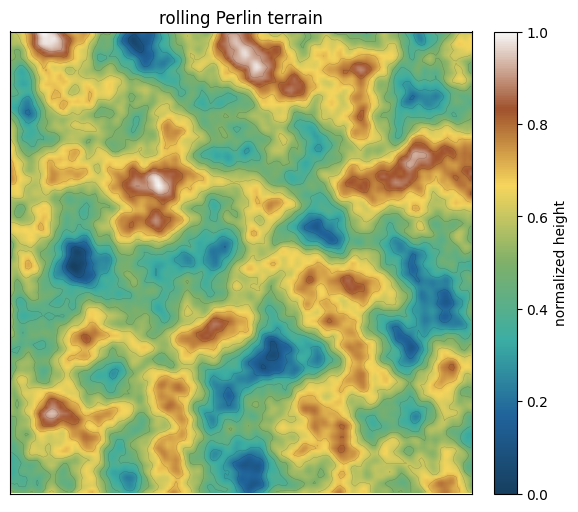

In [2]:
base_config = NoiseConfig(
    width=160,
    height=160,
    scale=5.0,
    octaves=4,
    persistence=0.50,
    lacunarity=2.0,
    seed=18,
)

base_snapshot = TerrainGenerator(base_config).snapshot("rolling Perlin terrain")
stats = base_snapshot.stats()

print(f"Terrain array shape: {base_snapshot.heights.shape}")
print(f"height min={stats['min']:.3f}, max={stats['max']:.3f}, mean={stats['mean']:.3f}, std={stats['std']:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
image = plot_terrain(base_snapshot, ax=ax)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="normalized height")
plt.show()

## 4. Compare Against Plain Random Noise

Plain random values make TV static: each cell is unrelated to its neighbors.

Perlin noise is still pseudo-random, but nearby cells are correlated, so it forms continuous hills and valleys.

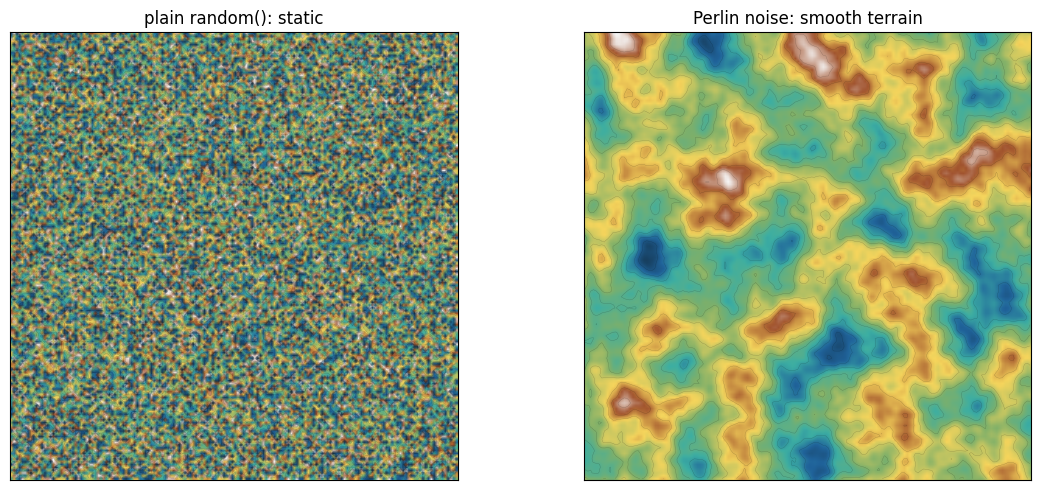

Static std: 0.290
Perlin std: 0.162


In [3]:
rng = np.random.default_rng(18)
static_heights = rng.random(base_snapshot.heights.shape)
static_snapshot = TerrainSnapshot("plain random static", base_config, static_heights)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_terrain(static_snapshot, title="plain random(): static", ax=axes[0])
plot_terrain(base_snapshot, title="Perlin noise: smooth terrain", ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Static std: {np.std(static_snapshot.heights):.3f}")
print(f"Perlin std: {np.std(base_snapshot.heights):.3f}")

## 5. Octaves: From Hills to Mountains

Octaves stack multiple noise layers:

- low octaves: broad rolling hills,
- more octaves: smaller ridges and rough detail,
- persistence: how strongly the small detail survives.

<details>
<summary>Minecraft connection</summary>

Terrain generators usually combine several noise maps: height, caves, moisture, temperature, and biome boundaries. This notebook focuses on the height-map idea.

</details>

**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
octave_settings = [1, 2, 4, 7]

octave_snapshots = [
    TerrainGenerator(
        NoiseConfig(
            width=140,
            height=140,
            scale=5.0,
            octaves=octaves,
            persistence=0.55,
            lacunarity=2.0,
            seed=18,
        )
    ).snapshot(f"{octaves} octave{'s' if octaves != 1 else ''}")
    for octaves in octave_settings
]

fig, axes = plt.subplots(1, len(octave_snapshots), figsize=(15, 4))

for ax, snapshot in zip(axes, octave_snapshots):
    plot_terrain(snapshot, ax=ax)

plt.tight_layout()

plt.show()


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
for snapshot in octave_snapshots:
    stats = snapshot.stats()
    print(f"{snapshot.label:<9} std={stats['std']:.3f} mean={stats['mean']:.3f}")


## 6. Persistence: Smooth Hills vs Rocky Detail

`persistence` controls how much each smaller octave matters.

- low persistence: smooth, soft hills,
- medium persistence: balanced terrain,
- high persistence: jagged, rocky detail.

**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
persistence_values = [0.25, 0.50, 0.80]

persistence_snapshots = [
    TerrainGenerator(
        NoiseConfig(
            width=150,
            height=150,
            scale=5.0,
            octaves=6,
            persistence=persistence,
            lacunarity=2.0,
            seed=18,
        )
    ).snapshot(f"persistence {persistence:.2f}")
    for persistence in persistence_values
]

fig, axes = plt.subplots(1, len(persistence_snapshots), figsize=(14, 4.5))

for ax, snapshot in zip(axes, persistence_snapshots):
    plot_terrain(snapshot, ax=ax)

plt.tight_layout()

plt.show()


**Run the experiment.** Advance the algorithm and collect the state changes that make the behavior visible.


In [ ]:
for snapshot in persistence_snapshots:
    stats = snapshot.stats()
    print(f"{snapshot.label:<16} std={stats['std']:.3f} mean={stats['mean']:.3f}")


## 7. Animate the Terrain Parameters

The animation keeps the same random seed and increases octave count. The broad landforms stay related, but smaller details appear as more noise layers are added.

**Inspect the result.** Render the current state so the algorithm is easier to reason about.


In [ ]:
animation_snapshots = [
    TerrainGenerator(
        NoiseConfig(
            width=120,
            height=120,
            scale=5.0,
            octaves=octaves,
            persistence=0.62,
            lacunarity=2.0,
            seed=18,
        )
    ).snapshot(f"{octaves} octave{'s' if octaves != 1 else ''}")
    for octaves in range(1, 8)
]

fig, ax = plt.subplots(figsize=(5.5, 5.2))

image = ax.imshow(animation_snapshots[0].heights, cmap=terrain_cmap, interpolation="bilinear", origin="lower")

ax.set_xticks([])

ax.set_yticks([])

ax.set_title(animation_snapshots[0].label)


**Helper functions.** Define `update_terrain_frame` so the later cells stay focused on behavior.


In [ ]:
def update_terrain_frame(frame_index: int):
    snapshot = animation_snapshots[frame_index]
    image.set_array(snapshot.heights)
    ax.set_title(f"{snapshot.label} | persistence 0.62")
    return (image,)

terrain_animation = animation.FuncAnimation(
    fig,
    update_terrain_frame,
    frames=len(animation_snapshots),
    interval=650,
    blit=True,
)

plt.close(fig)

HTML(terrain_animation.to_jshtml())


## 8. Playground: Turn Heights into Biomes

A terrain engine often uses thresholds:

- low values become water,
- middle values become plains or forest,
- high values become mountains and snow.

This is how a smooth height map starts to feel like a game world.

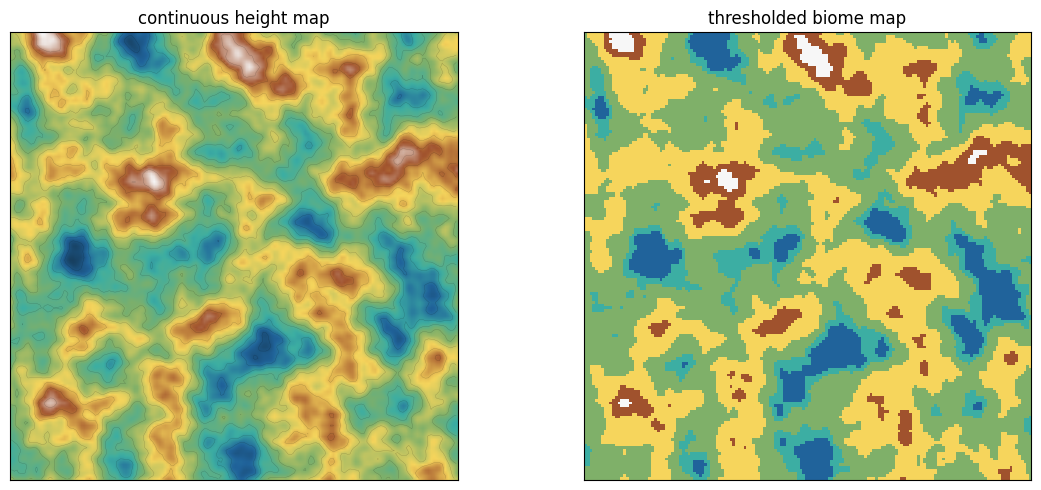

water   :   6.6%
shore   :   9.8%
grass   :  41.8%
hill    :  34.1%
mountain:   6.8%
snow    :   0.9%


In [7]:
biome_names = np.array(["water", "shore", "grass", "hill", "mountain", "snow"])
biome_colors = ["#20639B", "#3CAEA3", "#7FB069", "#F6D55C", "#A0522D", "#F7F7F7"]
biome_cmap = LinearSegmentedColormap.from_list("biomes", biome_colors, N=len(biome_colors))
thresholds = [0.28, 0.38, 0.58, 0.76, 0.90]
biome_map = np.digitize(base_snapshot.heights, thresholds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_terrain(base_snapshot, title="continuous height map", ax=axes[0])
axes[1].imshow(biome_map, cmap=biome_cmap, interpolation="nearest", origin="lower", vmin=0, vmax=len(biome_colors) - 1)
axes[1].set_title("thresholded biome map")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.tight_layout()
plt.show()

biome_counts = np.bincount(biome_map.ravel(), minlength=len(biome_names))
for name, count in zip(biome_names, biome_counts):
    percent = 100 * count / biome_map.size
    print(f"{name:<8}: {percent:>5.1f}%")

## 9. Replay the Terrain Settings

The visual output changes because the parameters change. This replay summarizes the important knobs from the generated snapshots.

In [8]:
class TerrainReplay:
    def __init__(self, snapshots: list[TerrainSnapshot]):
        self.snapshots = snapshots

    def show(self) -> None:
        for snapshot in self.snapshots:
            stats = snapshot.stats()
            config = snapshot.config
            print(
                f"{snapshot.label:<18} "
                f"octaves={config.octaves:<2} "
                f"persistence={config.persistence:.2f} "
                f"scale={config.scale:.1f} "
                f"std={stats['std']:.3f}"
            )


TerrainReplay([base_snapshot, *octave_snapshots, *persistence_snapshots]).show()

rolling Perlin terrain octaves=4  persistence=0.50 scale=5.0 std=0.162
1 octave           octaves=1  persistence=0.55 scale=5.0 std=0.199
2 octaves          octaves=2  persistence=0.55 scale=5.0 std=0.168
4 octaves          octaves=4  persistence=0.55 scale=5.0 std=0.157
7 octaves          octaves=7  persistence=0.55 scale=5.0 std=0.156
persistence 0.25   octaves=6  persistence=0.25 scale=5.0 std=0.181
persistence 0.50   octaves=6  persistence=0.50 scale=5.0 std=0.160
persistence 0.80   octaves=6  persistence=0.80 scale=5.0 std=0.136


## What You Should Remember

- Perlin noise is smooth pseudo-randomness, not independent static.
- The algorithm puts gradient arrows on a lattice, measures dot products, then blends them with a smooth fade curve.
- Octaves stack multiple noise layers so large hills can carry smaller detail.
- Persistence controls how strongly those smaller layers affect the terrain.
- A procedural world can start as a 2D height map, then become terrain by coloring values or thresholding them into biomes.

<details>
<summary>Quick self-check</summary>

If a map looks like TV static, the values are too independent. If it looks like terrain, nearby points are correlated. Perlin noise creates that correlation on purpose.
</details>

## Visual Trace + Rigor Studio

**Problem frame.** Create smooth pseudo-random structure for terrain and texture.

**Interactive animation target.** Animate octaves accumulating into a final terrain map.

**Correctness handle.** Nearby points share related gradients, which makes the output smooth rather than white noise.

**Complexity handle.** O(samples * octaves) for a generated grid.

**Failure mode to test.** Too many high-frequency octaves can erase the smoothness that makes Perlin noise useful.

**Studio task.** Compare one-octave terrain with multi-octave terrain and name the visual tradeoff.


In [ ]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, AlgorithmTrace, TraceStep, render_trace_table

# Convert the implementation above into snapshots:
# trace = AlgorithmTrace("Topic trace")
# trace.append("start", {"your_state": ...}, "What changed?", invariant="What remains true?")
# AlgorithmPlayer(trace, your_renderer).display()
print("Use AlgorithmTrace to turn this notebook's algorithm into a step-by-step visual player.")
